In [ ]:
# This notebook applies the following Deep Learning Model
# Convolutional Neural Network (CNN)
# Preprocessing: 0,1 rescaling
#    epochs = 10
#    batch_size = 200
###

# 0. Preparation
###
# Importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import itertools

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from keras.utils import to_categorical

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import cm



In [ ]:
# Mounting GoogleDrive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading data file from GoogleDrive
df = pd.read_pickle("/content/drive/My Drive/Data Science/Team Project X-Rays/Dataframes/df_basic_1.4.pkl")
df.head()

# Define data name
df_name = "Baseline 1.4"

# Define random subsample for testing code
#df = df.sample(500)


In [ ]:
# Explore Data
###

# Check data type is DataFrame
print(type(df))

# Show dimensions
print(df.shape)

# Show labels
print(df.Case.value_counts())

# Check distributions after normalisation
df.describe()



<class 'pandas.core.frame.DataFrame'>
(21105, 4098)
Case
Normal             10191
Lung_Opacity        6012
COVID               3564
Viral Pneumonia     1338
Name: count, dtype: int64


,PX_1,PX_2,PX_3,PX_4,PX_5,PX_6,PX_7,PX_8,PX_9,PX_10,...,PX_4087,PX_4088,PX_4089,PX_4090,PX_4091,PX_4092,PX_4093,PX_4094,PX_4095,PX_4096
count,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,...,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000,21105.000000
mean,42.727790,33.668657,33.446956,34.641838,35.782516,36.980858,37.975503,38.742099,39.627955,40.497891,...,148.859038,138.535134,126.862213,114.337835,100.699550,87.301398,75.467851,65.328879,58.607202,60.391803
std,61.404887,53.275717,52.336637,52.416730,52.688332,53.027111,53.557134,54.049191,54.539456,55.109691,...,69.108036,72.401729,75.401226,77.495805,78.369439,78.194965,76.628920,74.093986,71.465077,72.464377
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,116.000000,94.000000,63.000000,32.000000,16.000000,9.000000,6.000000,3.000000,2.000000,2.000000
50%,12.000000,9.000000,8.000000,9.000000,10.000000,10.000000,11.000000,11.000000,12.000000,12.000000,...,167.000000,157.000000,144.000000,128.000000,104.000000,73.000000,44.000000,26.000000,20.000000,23.000000
75%,58.000000,39.000000,40.000000,45.000000,50.000000,55.000000,58.000000,60.000000,63.000000,64.000000,...,200.000000,194.000000,188.000000,180.000000,170.000000,157.000000,141.000000,122.000000,105.000000,107.000000
max,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [ ]:
# Check missing values
print(df.info())

print("Missing vars in columns:\n", df.isna().sum())
print("Number of total missing vars:", df.isna().sum().sum())
print("Number of total missing vars (% of all obs):", (df.isna().sum().sum())/(df.shape[0]*df.shape[1]))

# No missing vars. We can continue the ML modelling.

<class 'pandas.core.frame.DataFrame'>
Index: 21105 entries, 0 to 21164
Columns: 4098 entries, Name to PX_4096
dtypes: object(2), uint8(4096)
memory usage: 82.9+ MB
None
Missing vars in columns:
 Name       0
Case       0
PX_1       0
PX_2       0
PX_3       0
          ..
PX_4092    0
PX_4093    0
PX_4094    0
PX_4095    0
PX_4096    0
Length: 4098, dtype: int64
Number of total missing vars: 0
Number of total missing vars (% of all obs): 0.0


In [ ]:
# 1. Data preprocessing
###

# Create categorical variable from Case
df["Case"] = df.Case.replace({"Normal": 0, "COVID": 1, "Lung_Opacity": 2, "Viral Pneumonia": 3})
df.Case.astype(int)

# Check construction
print(df.Case.value_counts())

# Split data into target and features
target = df.Case

# Features data: Drop Names and target
data = df.drop(["Name", "Case"], axis = 1)
data.head()
data.shape

# Split data into training and Test sets, save random state
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size = 0.2, random_state = 123)



Case
0    10191
2     6012
1     3564
3     1338
Name: count, dtype: int64


In [ ]:
# Standardisation
###
# Choose rescaling to 0 and 1
# So far, no standard scaler

# Rescale pixels to 0 and 1
X_train = X_train / 255
X_test = X_test / 255

# Instantiate StandardScaler function
#sc = StandardScaler()

# Standardize the data on the training set first and store the mean and std (scaler.fit_transform)
#X_train = sc.fit_transform(X_train)

# Then apply the mean and std from the training data to standardize the test data (scaler.transform)
# This prevents the model to learn from the test data but only from the train data (avoid data leakage)
#X_test = sc.transform(X_test)


In [ ]:
# Transform features (X) into 4 dimensional array
###
# Show dimensions of X_Train before: 20000 x 4069
print(X_train.shape)

# Now spread picture again into 64 x 64 with one channel.
X_train = np.reshape(X_train, (-1 , 64, 64, 1))
print(X_train.shape)

# So X_train becomes a matrix of dimensionms 20000 x 64 x 64 x 1
#  (nb_images, width, height, depth)

# Check X_test dimensions - ok
X_test = np.reshape(X_test, (-1 , 64, 64, 1))
print(X_test.shape)


(16884, 4096)
(16884, 64, 64, 1)
(4221, 64, 64, 1)


In [ ]:
# Transform labels into binary categorical vectors
###
# Show dimensions before:
# Vectors of dimensions number_images x 1
print(y_train.shape)
print(y_test.shape)

# Transform labels of y_train and y_test
# into binary categorical vectors (One hot)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Show dimensions after - ok
# Matrixes of dimensions number_images x 4 and number_images x 4
print(y_train.shape)
print(y_test.shape)

(16884,)
(4221,)
(16884, 4)
(4221, 4)


In [ ]:
# Build Convolutional Model structure
###
# Instantiate an input layer with shape 64x64x1
inputs = Input(shape = (64, 64, 1), name = "Input")

# Instantiate convolutional layer
# 32 convolutional matrices in the layer
first_layer = Conv2D(filters = 32,
                     # 5x5 convolutional kernels (25 neurons per filter)
                     kernel_size = (5, 5),
                     # kernel cannot exceed the edges of the image
                     padding = 'valid',
                     # activation function "relu"
                     activation = 'relu')

# instantiate max-pooling layer as second layer
# Maximum of pooling is computed on 2x2 size pieces
second_layer = MaxPooling2D(pool_size = (2,2))

# Add layers to the model
x = first_layer(inputs)
x = second_layer(x)

In [ ]:
# instantiate a dropout layer as thirdlayer
third_layer = Dropout(rate = 0.2)

# instantiate a flattening layer as fourth layer
# flattes matrix into a vector to proceed
fourth_layer = Flatten()

# instantiate dense layer with 128 neurons as fifth layer
# activation set to relu
fifth_layer = Dense(units = 128,
                    activation = "relu")

# instantiate output layer with 4 neurons
# Set output neurons = number of labels (4)
output_layer = Dense(units = 4,
                     activation = "softmax")

# add above layers to the model
x = third_layer(x)
x = fourth_layer(x)
x = fifth_layer(x)
outputs = output_layer(x)

# instantiate model
model = Model(inputs = inputs, outputs = outputs)

In [ ]:
# compile model

# Time model computation
import time
start_time = time.time()

# Define loss function as categorical_crossentropy
model.compile(loss = "categorical_crossentropy",
              # Gradient Descent algortithm (optimizer) is "adam"
              optimizer = "adam",
              # Evaluation metric to choose is accuracy
              metrics = ["accuracy"])

# Train model on 10 epochs, batch size = 200
# and test_split of 0.2
training_history = model.fit(X_train, y_train,
                             validation_split = 0.2,
                             epochs = 10,
                             batch_size = 200)


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 59s 848ms/step - accuracy: 0.5212 - loss: 1.2023 - val_accuracy: 0.7065 - val_loss: 0.7064
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 80s 822ms/step - accuracy: 0.7423 - loss: 0.6517 - val_accuracy: 0.7530 - val_loss: 0.6180
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 83s 835ms/step - accuracy: 0.7713 - loss: 0.5794 - val_accuracy: 0.7714 - val_loss: 0.5838
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 82s 849ms/step - accuracy: 0.8018 - loss: 0.5284 - val_accuracy: 0.7791 - val_loss: 0.5604
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 80s 811ms/step - accuracy: 0.8151 - loss: 0.4906 - val_accuracy: 0.7815 - val_loss: 0.5436
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 84s 849ms/step - accuracy: 0.8227 - loss: 0.4598 - val_accuracy: 0.7898 - val_loss: 0.5310
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 55s 816ms/step - accuracy: 0.8297 - loss: 0.4424 - val_accuracy: 0.8188 - val_loss: 0.4927
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 81s 802ms/step - accuracy: 0.8455 - loss: 0.4081 - val_accu

In [ ]:
# Model results
###
# store the training and test accuracies obtained during training
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

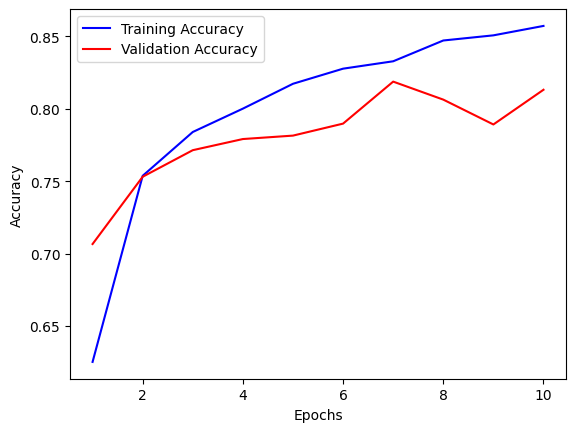

In [ ]:
# Plot evolution of accuracies throughout the training
###
# Axis labels
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Training sample accuracy curve
plt.plot(np.arange(1 , 11, 1),
         training_history.history['accuracy'],
         label = 'Training Accuracy',
         color = 'blue')

# Test sample accuracy curve
plt.plot(np.arange(1 , 11, 1),
         training_history.history['val_accuracy'],
         label = 'Validation Accuracy',
         color = 'red')

# Legend display
plt.legend()

# Figure display
plt.show()

In [ ]:
# Model results
###
# make predictions of labels on x_test
test_pred = model.predict(X_test)
print("Shape of predictions:", test_pred.shape)
# 2 Dimensional matrix of 10k x 10 dimension

# apply argmax on predictions to obtain vectors of integeres
# choose axis = 1 to perform argmax on columns
test_pred_class = test_pred.argmax(axis = 1)
print("Shape of predictions after argmax:", test_pred_class.shape)
# 1 Dimensional Vector of 10k x 1 dimension

y_test_class = y_test.argmax(axis = 1)

# show classification report
print(metrics.classification_report(y_test_class, test_pred_class))

# Measure time
model1_time = (time.time() - start_time)/60

# Modelling Time
print("Model 1: --- %s minutes ---" % model1_time)

132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
Shape of predictions: (4221, 4)
Shape of predictions after argmax: (4221,)
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      2103
           1       0.68      0.82      0.74       681
           2       0.81      0.76      0.78      1165
           3       0.92      0.88      0.90       272

    accuracy                           0.82      4221
   macro avg       0.82      0.83      0.82      4221
weighted avg       0.83      0.82      0.82      4221



[[1793  136  160   14]
 [  74  557   47    3]
 [ 162  118  881    4]
 [  14   13    6  239]]


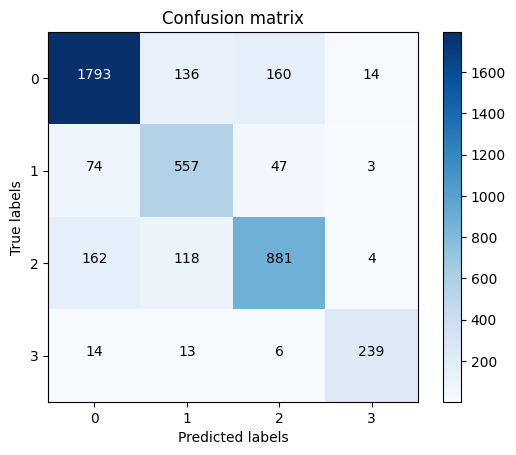

In [ ]:
# Show confusion matrix
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)
print(cnf_matrix)

# Display a confusion matrix as a colored table
classes = range(0, 4)

plt.figure()

plt.imshow(cnf_matrix, interpolation='nearest',cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i, j in itertools.product(range(cnf_matrix.shape[0]), range(cnf_matrix.shape[1])):
    plt.text(j, i, cnf_matrix[i, j],
             horizontalalignment="center",
             color="white" if cnf_matrix[i, j] > ( cnf_matrix.max() / 2) else "black")

plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()
